In [2]:
import pandas as pd
import numpy as np

# Генерация синтетического датасета "Рынок недвижимости" для лабораторной работы
np.random.seed(42)
n_samples = 510

data = {
    'id': np.arange(1, n_samples + 1),
    'price': np.random.randint(40000, 350000, size=n_samples).astype(float),
    'rooms': np.random.randint(1, 6, size=n_samples).astype(float),
    'area': np.round(np.random.uniform(30.0, 160.0, size=n_samples), 1),
    'city': np.random.choice(['Ashgabat', 'Mary', 'Chardzhou', 'Dashoguz'], size=n_samples),
    'condition': np.random.choice(['New', 'Good', 'Old'], size=n_samples),
    'year_built': np.random.randint(1980, 2026, size=n_samples),
    'has_parking': np.random.choice(['Yes', 'No'], size=n_samples)
}

df = pd.DataFrame(data)

# Искусственное добавление пропусков (Missing Values) для аудита данных
df.loc[df.sample(25).index, 'price'] = np.nan
df.loc[df.sample(15).index, 'rooms'] = np.nan

# Искусственное добавление полных дубликатов строк
df = pd.concat([df, df.iloc[:10]], ignore_index=True)

# Проверка и вывод размерности полученного датасета
print(f"Количество строк в датасете: {df.shape[0]}")
print(f"Количество столбцов в датасете: {df.shape[1]}")


Количество строк в датасете: 520
Количество столбцов в датасете: 8


# 1. Постановка задачи (Business Understanding)

**Описание данных:** Данный датасет содержит информацию о рынке недвижимости, включая характеристики объектов (цена, площадь, количество комнат, город, состояние здания, год постройки и наличие парковки).
**Заказчик анализа:** Аналитический отдел инвестиционной компании или крупное агентство недвижимости.
**Задачи ИАД (Интеллектуального анализа данных):**
1. Провести базовый аудит качества данных: выявить пропуски, полные дубликаты и аномальные значения.
2. Подготовить рекомендации и план по очистке данных для их дальнейшего использования в моделях машинного обучения.


In [3]:
# 2. Паспорт датасета (Data Understanding)

# Выводим точный размер полученного датасета
print(f"Количество строк в таблице: {df.shape[0]}")
print(f"Количество столбцов в таблице: {df.shape[1]}")

# Выводим типы данных для каждого столбца
print("\nСписок признаков и их типы данных:")
print(df.dtypes)


Количество строк в таблице: 520
Количество столбцов в таблице: 8

Список признаков и их типы данных:
id               int64
price          float64
rooms          float64
area           float64
city            object
condition       object
year_built       int64
has_parking     object
dtype: object


In [4]:
# 3. Аудит качества данных (Пропуски и Дубликаты)

# 3.1. Расчет количества и доли пропущенных значений (Missing Values)
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Проверка на пропущенные значения по столбцам:")
for column in df.columns:
    print(f"Столбец '{column}': {missing_count[column]} пропусков ({missing_percent[column]:.2f}%)")

# 3.2. Поиск полностью дублирующихся строк
duplicates = df.duplicated().sum()
print(f"\nКоличество полных дубликатов в таблице: {duplicates}")


Проверка на пропущенные значения по столбцам:
Столбец 'id': 0 пропусков (0.00%)
Столбец 'price': 26 пропусков (5.00%)
Столбец 'rooms': 15 пропусков (2.88%)
Столбец 'area': 0 пропусков (0.00%)
Столбец 'city': 0 пропусков (0.00%)
Столбец 'condition': 0 пропусков (0.00%)
Столбец 'year_built': 0 пропусков (0.00%)
Столбец 'has_parking': 0 пропусков (0.00%)

Количество полных дубликатов в таблице: 10


Количество выбросов в столбце 'price': 0


/tmp/ipykernel_552/1141651152.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='city', palette='Set2')


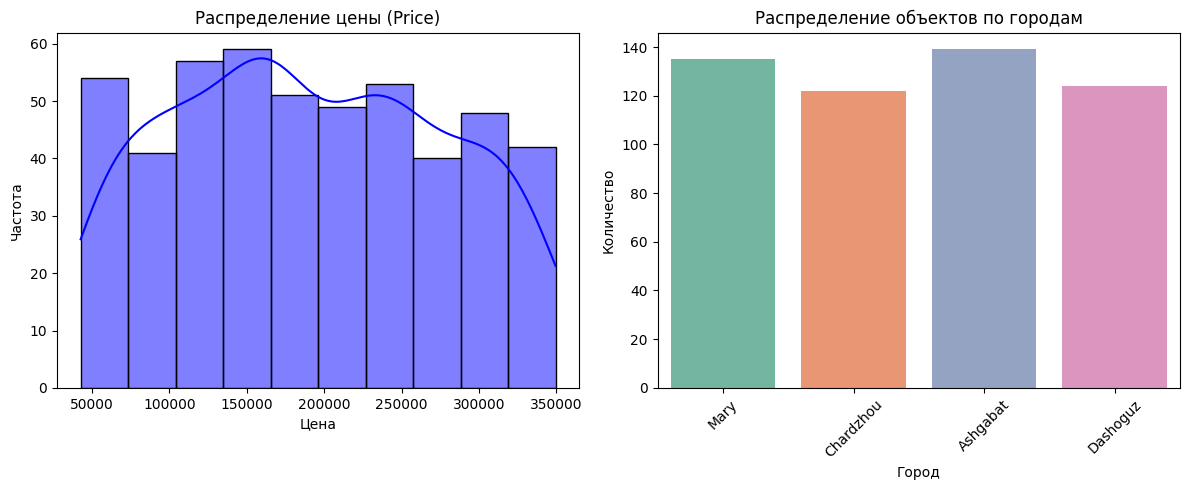

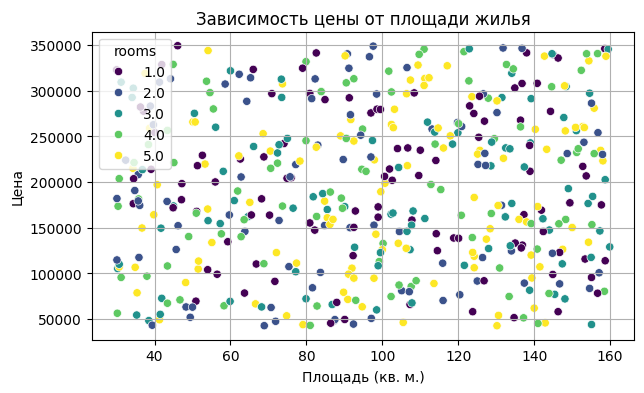

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3.3. Поиск выбросов (Outliers) методом IQR для столбца 'price'
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Количество выбросов в столбце 'price': {len(outliers)}")

# 4. Мини-EDA (Визуализация распределений)
plt.figure(figsize=(12, 5))

# Распределение стоимости жилья (Гистограмма с KDE)
plt.subplot(1, 2, 1)
sns.histplot(df['price'].dropna(), kde=True, color='blue')
plt.title('Распределение цены (Price)')
plt.xlabel('Цена')
plt.ylabel('Частота')

# Распределение объектов по городам
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='city', palette='Set2')
plt.title('Распределение объектов по городам')
plt.xlabel('Город')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Зависимость цены от площади жилья
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='area', y='price', hue='rooms', palette='viridis')
plt.title('Зависимость цены от площади жилья')
plt.xlabel('Площадь (кв. м.)')
plt.ylabel('Цена')
plt.grid(True)
plt.show()
